# Overview

This is a quick analysis of the performance of models.

The analysis could be extended to also look at the nature of the questions, such as co-occurence of target categories, and bias among answers.

Inspect AI features such as the reasoning-effort and tools such as the web browser could be applied and lead to a more in-depth analysis.


# Answer analysis

We want to visualize how each model responds. This will better inform the aggregate metric that was reported for it.

Load answer and target data for each question and model.


In [ ]:
import pandas as pd
import ast
data_dir = "data" # files were copied from logs-local/
df_samples = pd.read_csv(f"{data_dir}/structured_samples.csv")
df_samples['answer'] = df_samples['answer'].apply(ast.literal_eval)
df_samples['target'] = df_samples['target'].apply(ast.literal_eval)
df_samples

,task_index,model,answer,target
0,0,models/gemini-2.5-pro-preview-05-06,[E],"[E, F]"
1,1,models/gemini-2.5-pro-preview-05-06,[H],[H]
2,2,models/gemini-2.5-pro-preview-05-06,"[E, B, G, F]",[F]
3,3,models/gemini-2.5-pro-preview-05-06,[H],"[B, H]"
4,4,models/gemini-2.5-pro-preview-05-06,[G],[G]
...,...,...,...,...
58,2,mistral-large-latest,"[E, B, F]",[F]
59,3,mistral-large-latest,"[B, H]","[B, H]"
60,4,mistral-large-latest,"[B, G]",[G]
61,5,mistral-large-latest,"[B, C, D]","[C, D]"


In [80]:
# Function to calculate hits, false alarms, and misses
def calculate_metrics(row):
    answer_set = set(row['answer'])
    target_set = set(row['target'])
    hits = len(answer_set & target_set)
    false_alarms = len(answer_set - target_set)
    misses = len(target_set - answer_set)
    return pd.Series({'hits': hits, 'false_alarms': false_alarms, 'misses': misses})

# Apply the function to each row
metrics = df_samples.apply(calculate_metrics, axis=1)

# Concatenate the new metrics with the original DataFrame
df_samples_extended = pd.concat([df_samples, metrics], axis=1)
df_samples_extended

,task_index,model,answer,target,hits,false_alarms,misses
0,0,models/gemini-2.5-pro-preview-05-06,[E],"[E, F]",1,0,1
1,1,models/gemini-2.5-pro-preview-05-06,[H],[H],1,0,0
2,2,models/gemini-2.5-pro-preview-05-06,"[E, B, G, F]",[F],1,3,0
3,3,models/gemini-2.5-pro-preview-05-06,[H],"[B, H]",1,0,1
4,4,models/gemini-2.5-pro-preview-05-06,[G],[G],1,0,0
...,...,...,...,...,...,...,...
58,2,mistral-large-latest,"[E, B, F]",[F],1,2,0
59,3,mistral-large-latest,"[B, H]","[B, H]",2,0,0
60,4,mistral-large-latest,"[B, G]",[G],1,1,0
61,5,mistral-large-latest,"[B, C, D]","[C, D]",2,1,0


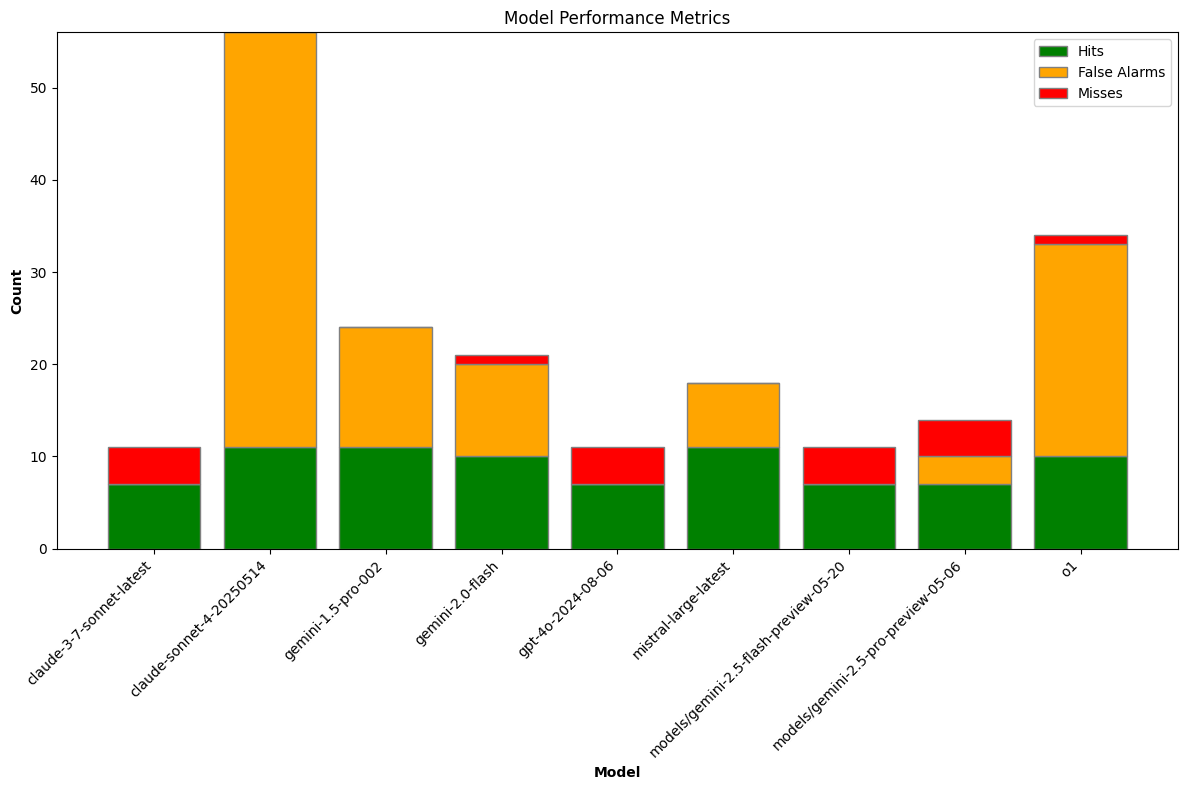

In [81]:
import matplotlib.pyplot as plt
import numpy as np

# Grouping the data by model and summing the metrics
model_metrics = df_samples_extended.groupby('model')[['hits', 'false_alarms', 'misses']].sum().reset_index()

# Plotting the stacked bar plot
fig, ax = plt.subplots(figsize=(12, 8))

# Define bar positions
r = np.arange(len(model_metrics))

# Create stacked bars
ax.bar(r, model_metrics['hits'], color='green', edgecolor='grey', label='Hits')
ax.bar(r, model_metrics['false_alarms'], bottom=model_metrics['hits'], color='orange', edgecolor='grey', label='False Alarms')
ax.bar(r, model_metrics['misses'], bottom=model_metrics['hits'] + model_metrics['false_alarms'], color='red', edgecolor='grey', label='Misses')

# Add labels and title
ax.set_xlabel('Model', fontweight='bold')
ax.set_ylabel('Count', fontweight='bold')
ax.set_title('Model Performance Metrics')
ax.set_xticks(r)
ax.set_xticklabels(model_metrics['model'], rotation=45, ha='right')

# Add legend
ax.legend()

plt.tight_layout()
plt.show()

# Observations

Clearly some models show much many false positives. Adjusting the prompt might improve this.

In [82]:
# Function to calculate precision, recall, and F1 score
def calculate_f1(row):
    hits = row['hits']
    false_alarms = row['false_alarms']
    misses = row['misses']
    
    precision = hits / (hits + false_alarms) if (hits + false_alarms) > 0 else 0
    recall = hits / (hits + misses) if (hits + misses) > 0 else 0
    f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return f1_score

# Apply the function to calculate F1 score for each row
df_samples_extended['f1_score'] = df_samples_extended.apply(calculate_f1, axis=1)

In [83]:
df_samples_extended[['f1_score', 'model']].groupby('model').mean()

,f1_score
model,
claude-3-7-sonnet-latest,0.809524
claude-sonnet-4-20250514,0.323810
gemini-1.5-pro-002,0.624490
gemini-2.0-flash,0.661905
gpt-4o-2024-08-06,0.809524
mistral-large-latest,0.747619
models/gemini-2.5-flash-preview-05-20,0.809524
models/gemini-2.5-pro-preview-05-06,0.723810
o1,0.551587


# Metric comparison

Let's compare our calculated F1 scores to those from Inspect AI.
They match! 

In [84]:
import json
with open(f"{data_dir}/logs.json", "r") as fp:
    logs = json.load(fp)
data_lst = []
for k, log in logs.items():
    model_name = log['eval']['model']
    score_name = log['results']['scores'][0]['name']
    score = log['results']['scores'][0]['metrics']['accuracy']['value']
    data_lst.append(dict(model=model_name, score_name=score_name, score=score))

df_scores = pd.DataFrame(data_lst)
df_scores.sort_values(by='score', ascending=False)

,model,score_name,score
2,google/gemini-2.5-flash-preview-05-20,multilabel_f1,0.809524
7,anthropic/claude-3-7-sonnet-latest,multilabel_f1,0.809524
5,openai/gpt-4o,multilabel_f1,0.809524
8,mistral/mistral-large-latest,multilabel_f1,0.747619
0,google/gemini-2.5-pro-preview-03-25,multilabel_f1,0.723810
4,google/gemini-2.0-flash,multilabel_f1,0.661905
6,google/gemini-1.5-pro,multilabel_f1,0.624490
1,openai/o1,multilabel_f1,0.551587
3,anthropic/claude-sonnet-4-20250514,multilabel_f1,0.323810


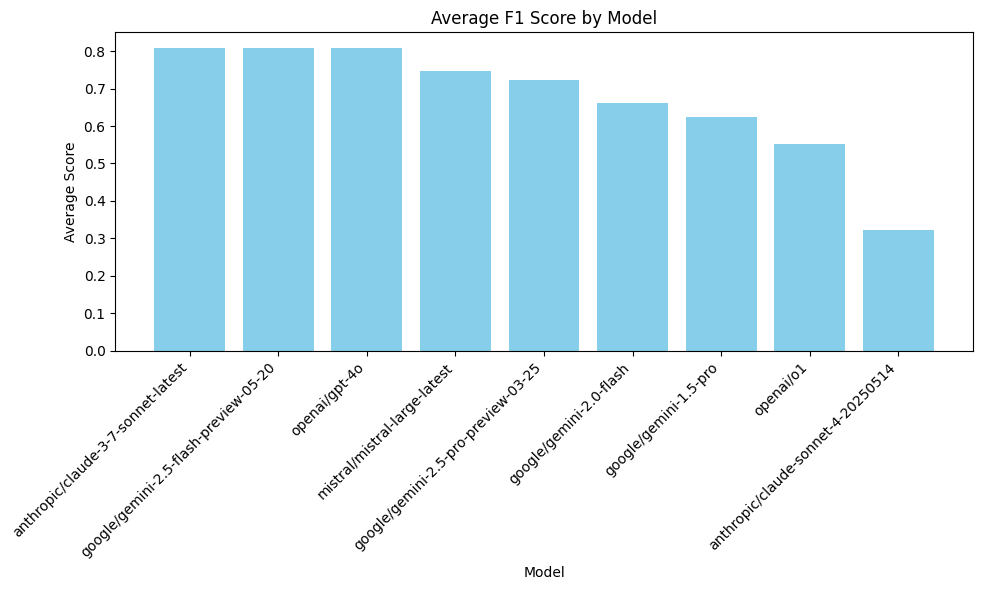

In [85]:
import matplotlib.pyplot as plt

# Grouping the data by model and calculating the mean score for each model
model_scores = df_scores.groupby('model')['score'].mean().reset_index()
model_scores = model_scores.sort_values(by='score', ascending=False)

# Plotting the bar plot
plt.figure(figsize=(10, 6))
plt.bar(model_scores['model'], model_scores['score'], color='skyblue')
plt.title('Average F1 Score by Model')
plt.xlabel('Model')
plt.ylabel('Average Score')
plt.xticks(rotation=45, ha='right')  # Rotate model names for better readability
plt.tight_layout()
plt.show()